# Model - CIS 2450 Final Project
K-Means on Joined OpenAlex + Semantic Scholar Data

This notebook joins `openalex_papers` with `semanticscholar_papers`, filters out rows with missing abstracts or TLDRs, vectorizes the text, and clusters the papers with K-Means.

In [38]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from scipy.sparse import csr_matrix, hstack
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler


In [39]:
# Load the joined dataset and keep only rows with both abstract and TLDR text
DB_PATH = Path("papers.db")
if not DB_PATH.exists():
    DB_PATH = Path("../papers.db")

JOINED_QUERY = """
SELECT
    o.openalex_id,
    o.doi,
    o.doi_normalized,
    o.title,
    o.publication_year,
    o.cited_by_count,
    o.author_count,
    o.primary_topic,
    o.primary_subfield,
    o.primary_field,
    o.primary_domain,
    s.abstract_text,
    s.tldr_text
FROM openalex_papers AS o
JOIN semanticscholar_papers AS s
    ON o.doi_normalized = s.doi_normalized
WHERE s.abstract_text IS NOT NULL
  AND TRIM(s.abstract_text) <> ''
  AND s.tldr_text IS NOT NULL
  AND TRIM(s.tldr_text) <> ''
"""

with sqlite3.connect(DB_PATH) as conn:
    df = pl.read_database(query=JOINED_QUERY, connection=conn)

print(f"Joined rows with abstract + TLDR: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Joined rows with abstract + TLDR: 15042
Columns: 13


openalex_id,doi,doi_normalized,title,publication_year,cited_by_count,author_count,primary_topic,primary_subfield,primary_field,primary_domain,abstract_text,tldr_text
str,str,str,str,i64,i64,i64,str,str,str,str,str,str
"""https://openalex.org/W43627070…","""https://doi.org/10.1016/j.patc…","""10.1016/j.patcog.2026.113208""","""RFAConv: Receptive-field atten…",2026,86,7,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""Computer Science""","""Physical Sciences""","""In the realm of deep learning,…","""It is revealed that current sp…"
"""https://openalex.org/W71290307…","""https://doi.org/10.1145/379651…","""10.1145/3796519""","""Model Context Protocol (MCP): …",2026,22,4,"""Security and Verification in C…","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""The Model Context Protocol (MC…","""A comprehensive threat taxonom…"
"""https://openalex.org/W44007028…","""https://doi.org/10.1109/tnnls.…","""10.1109/tnnls.2025.3646122""","""Graph Transformers: A Survey""",2026,16,7,"""Advanced Graph Neural Networks""","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Graph transformers are a recen…","""This survey provides an in-dep…"
"""https://openalex.org/W43969140…","""https://doi.org/10.1007/s11263…","""10.1007/s11263-025-02646-6""","""Deep Learning-Based Object Pos…",2026,14,10,"""Hand Gesture Recognition Syste…","""Human-Computer Interaction""","""Computer Science""","""Physical Sciences""","""Object pose estimation is a fu…","""This survey discusses the rece…"
"""https://openalex.org/W44043502…","""https://doi.org/10.1038/s41567…","""10.1038/s41567-025-03144-9""","""Dynamical simulations of many-…",2026,9,19,"""Neural Networks and Reservoir …","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Quantum circuits with local un…","""This work studies dual-unitary…"


In [40]:
# Build the structured feature block in Polars
year_median = df["publication_year"].drop_nulls().median()

structured_df = df.select([
    pl.col("publication_year").fill_null(year_median).cast(pl.Float64),
    pl.col("cited_by_count").fill_null(0).clip(lower_bound=0).log1p(),
    pl.col("author_count").fill_null(0).clip(lower_bound=0).log1p(),
    pl.col("primary_topic").fill_null("Unknown"),
    pl.col("primary_subfield").fill_null("Unknown"),
    pl.col("primary_field").fill_null("Unknown"),
    pl.col("primary_domain").fill_null("Unknown"),
])

structured_encoded = structured_df.to_dummies(columns=[
    "primary_topic",
    "primary_subfield",
    "primary_field",
    "primary_domain",
])

structured_matrix = structured_encoded.to_numpy()
structured_matrix = StandardScaler().fit_transform(structured_matrix)
structured_matrix = csr_matrix(structured_matrix)

print("Structured matrix shape:", structured_matrix.shape)


Structured matrix shape: (15042, 286)


In [41]:
# Vectorize abstract and TLDR text separately
abstract_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=2000,
    min_df=5,
)

tldr_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=750,
    min_df=3,
)

abstract_matrix = abstract_vectorizer.fit_transform(df["abstract_text"].to_list())
tldr_matrix = tldr_vectorizer.fit_transform(df["tldr_text"].to_list())

print("Abstract TF-IDF shape:", abstract_matrix.shape)
print("TLDR TF-IDF shape:", tldr_matrix.shape)


Abstract TF-IDF shape: (15042, 2000)
TLDR TF-IDF shape: (15042, 750)


In [42]:
# Combine structured and text features into one sparse matrix
X = hstack([
    structured_matrix,
    abstract_matrix,
    tldr_matrix,
], format="csr")

print("Combined feature matrix shape:", X.shape)


Combined feature matrix shape: (15042, 3036)


In [43]:
# Fit K-Means on the combined feature matrix
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X)

print(kmeans_model)
pl.DataFrame({"cluster": clusters}).group_by("cluster").len().sort("cluster")

KMeans(n_clusters=5, n_init=10, random_state=42)


cluster,len
i32,u32
0,13610
1,65
2,34
3,275
4,1058


In [44]:
# Add cluster labels back to the joined dataframe
df_clustered = df.with_columns(pl.Series("cluster", clusters))

df_clustered.select([
    "title",
    "publication_year",
    "primary_topic",
    "primary_subfield",
    "cluster",
]).head(10)

title,publication_year,primary_topic,primary_subfield,cluster
str,i64,str,str,i32
"""RFAConv: Receptive-field atten…",2026,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…",0
"""Model Context Protocol (MCP): …",2026,"""Security and Verification in C…","""Artificial Intelligence""",0
"""Graph Transformers: A Survey""",2026,"""Advanced Graph Neural Networks""","""Artificial Intelligence""",0
"""Deep Learning-Based Object Pos…",2026,"""Hand Gesture Recognition Syste…","""Human-Computer Interaction""",0
"""Dynamical simulations of many-…",2026,"""Neural Networks and Reservoir …","""Artificial Intelligence""",0
"""Deep contrastive learning enab…",2026,"""Computational Drug Discovery M…","""Computational Theory and Mathe…",4
"""Interval cancer, sensitivity, …",2026,"""AI in cancer detection""","""Artificial Intelligence""",0
"""SAM2-UNet: segment anything 2 …",2026,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…",0
"""What is wrong with your code g…",2026,"""Software Engineering Research""","""Information Systems""",0


In [45]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters, sample_size=2000, random_state=42)
print(f"Silhouette score: {score:.4f}")


Silhouette score: -0.1991


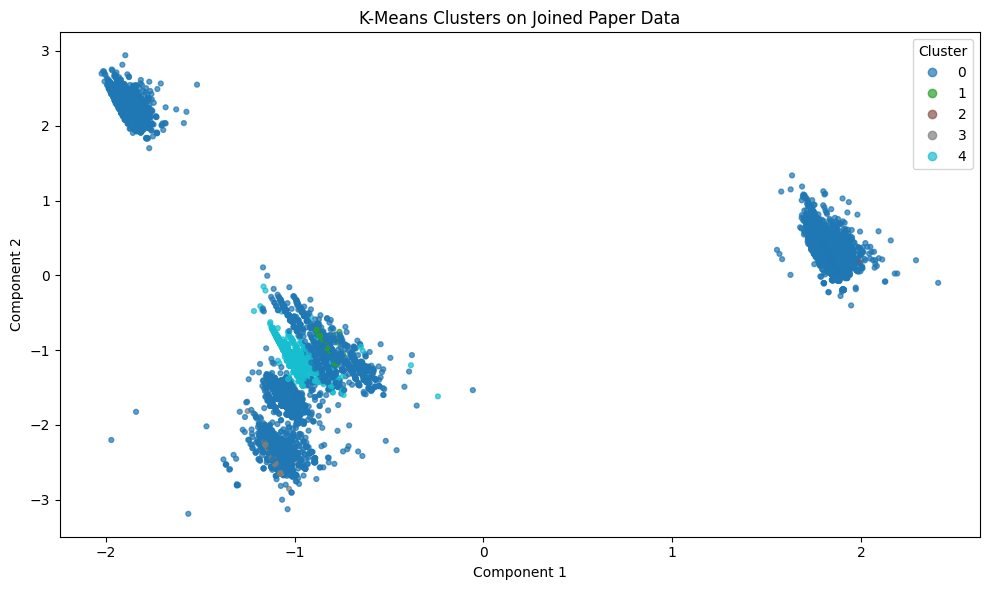

Explained variance ratio: [0.00878309 0.00782962]


In [46]:
# Project the sparse text-heavy matrix to 2D for visualization
# TruncatedSVD is the PCA-style reduction commonly used for sparse TF-IDF data.
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=clusters,
    cmap="tab10",
    s=12,
    alpha=0.7,
)
plt.title("K-Means Clusters on Joined Paper Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", svd.explained_variance_ratio_)


Answers to questions: The baseline model performs very poorly. A silhouette score below 0 means many points are closer to another cluster than they one they are assigned! The next 2-3 models we will implement will need to involve rescraping data. Vectorizing the tldrs and abstracts definitely causes some sort of curse of dimensionality. We will likely need a different strategy for parsing information out of tldrs and abstracts like keyword search (or ditch it all together, which could be detrimental because then we do not have any measure of the content of the paper). We also may need to consider changing the model we're choosing altogether. KMeans and PCA is visually useful, but in this case the data does not seem suited to clustering.

In [36]:
# Compare multiple values of k using inertia and sampled silhouette score
k_values = range(2, 11)
results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=2000, random_state=42)
    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": score,
    })
    print(f"k={k}: inertia={model.inertia_:.2f}, silhouette={score:.4f}")

results_df = pl.DataFrame(results)
results_df

k=2: inertia=4260651.43, silhouette=0.1820
k=3: inertia=4245368.10, silhouette=0.1843
k=4: inertia=4224082.82, silhouette=-0.2532
k=5: inertia=4195594.16, silhouette=-0.1991
k=6: inertia=4175669.57, silhouette=-0.0631
k=7: inertia=4153680.72, silhouette=-0.1199
k=8: inertia=4156312.05, silhouette=-0.1860
k=9: inertia=4125310.01, silhouette=-0.0741
k=10: inertia=4107110.38, silhouette=-0.1442


k,inertia,silhouette_score
i64,f64,f64
2,4.2607e6,0.182045
3,4.2454e6,0.184303
4,4.2241e6,-0.253193
5,4.1956e6,-0.199082
6,4.1757e6,-0.063054
7,4.1537e6,-0.119865
8,4.1563e6,-0.185998
9,4.1253e6,-0.074117
10,4.1071e6,-0.144241


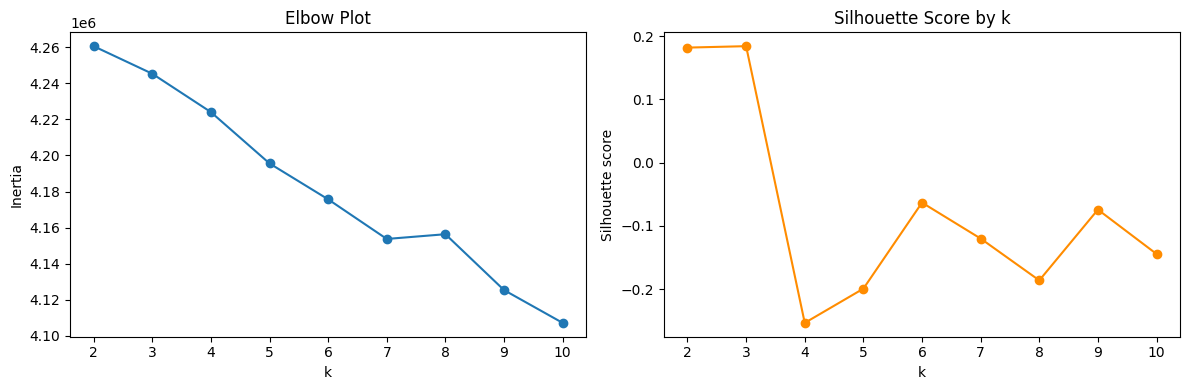

In [37]:
# Plot inertia and silhouette score across k values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results_df["k"].to_list(), results_df["inertia"].to_list(), marker="o")
axes[0].set_title("Elbow Plot")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(
    results_df["k"].to_list(),
    results_df["silhouette_score"].to_list(),
    marker="o",
    color="darkorange",
)
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

Clearly there are only 3 clusters but that may be because of topic clustering rather than the actual structure of the data. 